## Step 1 — Setup & Database Connection

Connect to the local SQLite database built from the FDA FAERS 2024 quarterly ASCII datasets (Q1–Q4). 
The database contains roughly 2.4 million demographic records and 9.6 million drug records across seven tables, 
all linked by a common `primaryid` key.

All analysis in this notebook queries that database directly using `pandas.read_sql_query`.

In [6]:
#This notebook performs early EDA on 5-FU reports from the FDA FAERS database for all quarters in the year of 2024.

# The goal is to understand the distribution of reports across different drug combinations, identify common adverse events, and explore
#  potential patterns in the data that could inform future modeling efforts. We will focus on the most frequently reported drug combinations 
#  involving 5-FU and analyze their associated adverse events to gain insights into their safety profiles.



#Set project root variables
from pathlib import Path
import sqlite3
import pandas as pd

project_root = Path.cwd().parents[0]
db_path = r"C:\Users\palla\OneDrive\Documents\Coding Projects\FDA_FAERS\database\faers.db"

conn = sqlite3.connect(db_path)

## Step 2 — Schema Inspection

Verify the tables present in the database before querying. The core FAERS tables are:

| Table | Contents |
|-------|----------|
| `demo` | Patient demographics — age, sex, weight, country, reporter occupation |
| `drug` | Drug records — name, role, route, dose, formulation |
| `reac` | Adverse reactions — MedDRA preferred terms |
| `indi` | Drug indications — what each drug was prescribed for |
| `outc` | Serious outcomes — death, hospitalization, life-threatening, etc. |
| `rpsr` | Report source — who submitted the report |
| `ther` | Therapy dates — start, end, duration |

We also check for any saved tables from previous notebook runs (e.g., `fluorouracil_filtered`).

In [7]:

tables = pd.read_sql_query(
"""
SELECT name
FROM sqlite_master
WHERE type='table'
ORDER BY name
""",
conn
)

tables

,name
0,demo
1,drug
2,faers_severity_dataset
3,fluorouracil_filtered
4,indi
5,outc
6,reac
7,rpsr
8,ther


## Step 3 — Drug Name Discovery & Normalization

Drug names in FAERS are free-text fields entered by reporters. The same drug appears under dozens of 
different spellings, brand names, salt variants, and combination strings. Before any analysis, 
we need to find all fluorouracil-containing records and consolidate them.

The workflow here is:
1. Use `LIKE '%FLUOROURACIL%'` to find every distinct drug name containing the string
2. Count records per variant to understand the distribution
3. Filter out variants with fewer than 10 reports — too sparse to analyze meaningfully
4. Save the result as `fluorouracil_filtered` for use throughout this and downstream notebooks

This kind of normalization step is essential in real-world pharmacovigilance work — 
skipping it means missing records or double-counting under different name variants.

In [8]:

like_5FU_tables = pd.read_sql_query("""

SELECT DISTINCT drugname
FROM drug
WHERE drugname LIKE '%FLUOROURACIL%'
ORDER BY drugname;
        """,
        conn)

like_5FU_tables                   


,drugname
0,5-FLUOROURACIL /00098801/
1,5fluorouracile
2,CALCIPOTRIENE\FLUOROURACIL
3,CARBOPLATIN;FLUOROURACIL
4,CYCLOPHOSPHAMIDE\EPIRUBICIN HYDROCHLORIDE\FLUO...
5,EPIRUBICIN;FLUOROURACIL
6,FLUOROURACIL
7,"FLUOROURACIL ACCORD 50 mg/ml, solution for inf..."
8,FLUOROURACIL ANABIOSIS
9,FLUOROURACIL CO [FLUOROURACIL]


In [9]:

tables = pd.read_sql_query(
"""
SELECT drugname, COUNT(*) AS reports
FROM drug
WHERE drugname LIKE '%FLUOROURACIL%'
ORDER BY drugname;
""",
conn
)

tables

,drugname,reports
0,FLUOROURACIL,13254


In [10]:
number_of_diff_FU = pd.read_sql_query("""SELECT
    drugname,
    COUNT(*) AS report_count
FROM drug
WHERE drugname LIKE '%FLUOROURACIL%'
GROUP BY drugname
ORDER BY report_count DESC;""", conn)

number_of_diff_FU

,drugname,report_count
0,FLUOROURACIL,12625
1,FLUOROURACIL\LEUCOVORIN CALCIUM\OXALIPLATIN,265
2,FLUOROURACIL\IRINOTECAN\LEUCOVORIN,124
3,FLUOROURACIL SODIUM,76
4,FLUOROURACIL\IRINOTECAN\LEUCOVORIN\OXALIPLATIN,55
5,FLUOROURACIL\LEUCOVORIN,29
6,CYCLOPHOSPHAMIDE\EPIRUBICIN HYDROCHLORIDE\FLUO...,25
7,FLUOROURACIL\LEUCOVORIN\OXALIPLATIN,12
8,TOLAK [FLUOROURACIL],4
9,FLUOROURACIL\IRINOTECAN,3


In [11]:
conn.execute("DROP TABLE IF EXISTS fluorouracil_filtered;")
conn.execute("""
CREATE TABLE fluorouracil_filtered AS
SELECT *
FROM drug
WHERE drugname IN (
    SELECT drugname
    FROM drug
    WHERE drugname LIKE '%FLUOROURACIL%'
    GROUP BY drugname
    HAVING COUNT(*) > 10
);
""")



In [12]:
FU_df_filtered = pd.read_sql_query("""
SELECT *
FROM fluorouracil_filtered
""", conn)

FU_df_filtered.shape

(13211, 21)

In [13]:
FU_df_filtered

,primaryid,caseid,drug_seq,role_cod,drugname,prod_ai,val_vbm,route,dose_vbm,cum_dose_chr,...,dechal,rechal,lot_num,exp_dt,nda_num,dose_amt,dose_unit,dose_form,dose_freq,source_quarter
0,113800407,11380040,24,SS,FLUOROURACIL,FLUOROURACIL,1,Unknown,"UNK, Cyclic",NaN,...,U,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Q1
1,113800407,11380040,25,SS,FLUOROURACIL,FLUOROURACIL,1,Unknown,UNK,NaN,...,U,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Q1
2,1177955113,11779551,38,C,FLUOROURACIL,FLUOROURACIL,1,NaN,UNK,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Cream,NaN,Q1
3,125820364,12582036,8,SS,FLUOROURACIL,FLUOROURACIL,1,Unknown,cycle 8 day 1,NaN,...,U,U,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Q1
4,125820364,12582036,9,SS,FLUOROURACIL,FLUOROURACIL,1,Unknown,UNK,NaN,...,U,U,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Q1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13206,247943981,24794398,2,SS,FLUOROURACIL,FLUOROURACIL,1,Unknown,9 cycles,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Q4
13207,247950291,24795029,2,SS,FLUOROURACIL,FLUOROURACIL,1,Intravenous (not otherwise specified),NaN,NaN,...,U,NaN,UNKNOWN,NaN,NaN,4654.0,MG,NaN,NaN,Q4
13208,93587883,9358788,3,SS,FLUOROURACIL,FLUOROURACIL,1,Parenteral,"UNK UNK,QCY",NaN,...,Y,NaN,NaN,NaN,NaN,NaN,NaN,NaN,/CYCLE,Q4
13209,93587883,9358788,4,SS,FLUOROURACIL,FLUOROURACIL,1,NaN,NaN,NaN,...,Y,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Q4


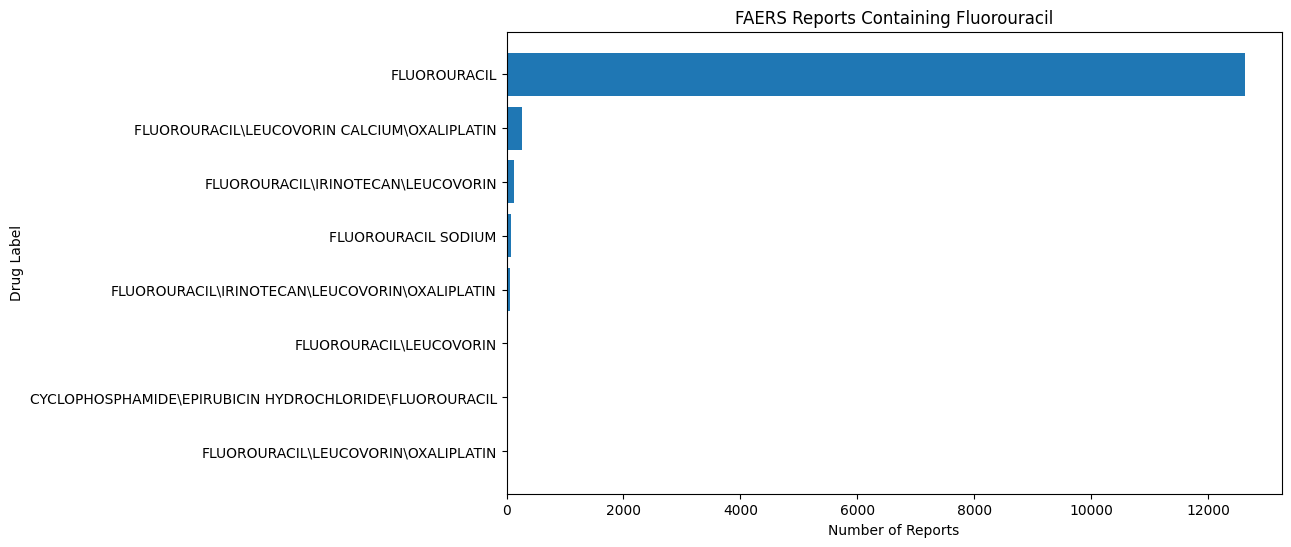

In [14]:

drug_counts = (
    FU_df_filtered
    .groupby("drugname")
    .size()
    .reset_index(name="reports")
    .sort_values("reports", ascending=False)
)

drug_counts.head(20)    


import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.barh(
    drug_counts["drugname"],
    drug_counts["reports"]
)

plt.xlabel("Number of Reports")
plt.ylabel("Drug Label")
plt.title("FAERS Reports Containing Fluorouracil")
plt.gca().invert_yaxis()

plt.show()

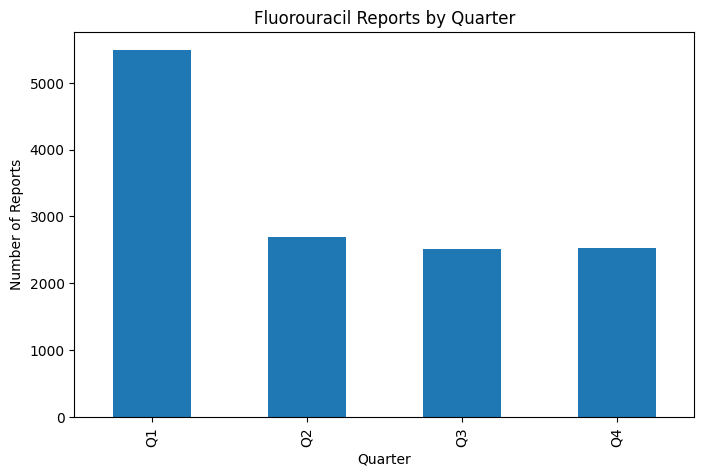

In [15]:
import matplotlib.pyplot as plt

quarter_counts = FU_df_filtered.groupby("source_quarter").size()

quarter_counts = quarter_counts.reindex(["Q1", "Q2", "Q3", "Q4"], fill_value=0)

quarter_counts.plot(kind="bar", figsize=(8,5))

plt.xlabel("Quarter")
plt.ylabel("Number of Reports")
plt.title("Fluorouracil Reports by Quarter")
plt.show()

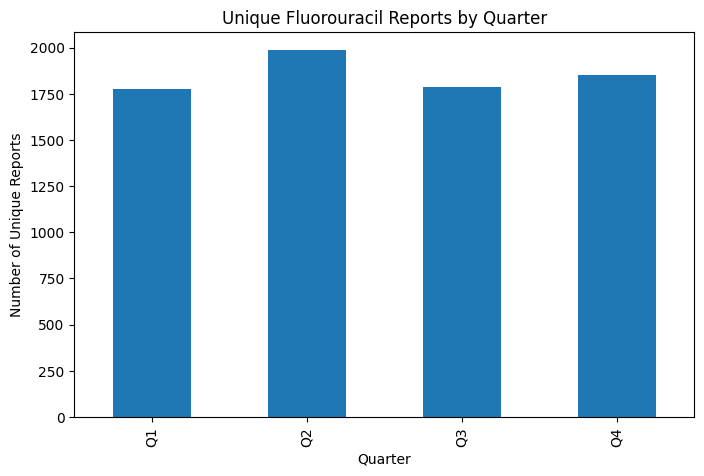

In [16]:
import matplotlib.pyplot as plt

quarter_counts = FU_df_filtered.groupby("source_quarter")["primaryid"].nunique()

quarter_counts = quarter_counts.reindex(["Q1", "Q2", "Q3", "Q4"], fill_value=0)

quarter_counts.plot(kind="bar", figsize=(8,5))

plt.xlabel("Quarter")
plt.ylabel("Number of Unique Reports")
plt.title("Unique Fluorouracil Reports by Quarter")
plt.show()

## Step 4 — Data Completeness

Before building any downstream analysis, we need to know how complete the key fields actually are. 
FAERS is a spontaneous reporting system — reporters fill in what they know, and many fields are optional.

High null rates don't mean the data is broken. They mean that any analysis relying on that field 
only reflects the subset of reports where it was filled in — a potential selection bias worth knowing upfront. 
For example, if 90% of `dose_amt` values are missing, a dose-response analysis would only cover 10% of reports.

We check the columns most relevant to pharmacovigilance analysis: route, dosing fields, 
and dechallenge/rechallenge (whether the reaction stopped or returned when the drug was withdrawn or restarted).

In [17]:
key_cols = ['route', 'dose_amt', 'dose_unit', 'dose_form', 'dose_freq', 'dechal', 'rechal']

null_summary = (
    FU_df_filtered[key_cols]
    .isnull()
    .mean()
    .mul(100)
    .round(1)
    .reset_index()
)
null_summary.columns = ['column', 'pct_missing']
null_summary = null_summary.sort_values('pct_missing', ascending=False).reset_index(drop=True)
null_summary

,column,pct_missing
0,rechal,92.6
1,dose_freq,90.5
2,dose_form,70.5
3,dose_amt,56.0
4,dose_unit,56.0
5,dechal,35.4
6,route,28.9


## Step 5 — Drug Role Classification (`role_cod`)

Every drug in a FAERS report is assigned a role code indicating its suspected relationship to the adverse event:

| Code | Role | Meaning |
|------|------|---------|
| PS | Primary Suspect | Drug most likely responsible for the event |
| SS | Secondary Suspect | Possibly involved |
| C | Concomitant | Patient was taking it, but not suspected |
| I | Interacting | Involved through a drug-drug interaction |

In pharmacovigilance signal detection, analyses are typically restricted to **PS and SS** records only. 
Including concomitant drugs inflates reaction counts — those drugs may have had nothing to do with the event.

This distribution tells us how many of our 13,000+ records are actually *suspect* records 
versus background medications the patient happened to be on.

In [18]:
role_labels = {'PS': 'Primary Suspect', 'SS': 'Secondary Suspect', 'C': 'Concomitant', 'I': 'Interacting'}

role_counts = (
    FU_df_filtered
    .groupby('role_cod')
    .size()
    .reset_index(name='record_count')
    .assign(pct=lambda x: (x['record_count'] / x['record_count'].sum() * 100).round(1))
    .sort_values('record_count', ascending=False)
    .reset_index(drop=True)
)
role_counts['role_description'] = role_counts['role_cod'].map(role_labels)
role_counts[['role_cod', 'role_description', 'record_count', 'pct']]

,role_cod,role_description,record_count,pct
0,SS,Secondary Suspect,8581,65.0
1,C,Concomitant,2811,21.3
2,PS,Primary Suspect,1768,13.4
3,I,Interacting,51,0.4


## Step 6 — Route of Administration

Route tells us how the drug was administered. For fluorouracil this matters clinically:

- **Intravenous** routes are used in colorectal and appendiceal cancer chemotherapy (FOLFOX, FOLFIRI, HIPEC)
- **Topical/cream** formulations are used for actinic keratosis and basal cell carcinoma — 
a completely different disease and patient population

Any cancer-focused downstream analysis should exclude topical formulations to avoid mixing two 
unrelated clinical contexts. Here we look at the route distribution and flag records that should be excluded.

Note: `Unknown` is a common and valid value — reporters frequently omit route.

In [19]:
route_counts = (
    FU_df_filtered['route']
    .fillna('Not reported')
    .value_counts()
    .reset_index()
)
route_counts.columns = ['route', 'record_count']
route_counts['pct'] = (route_counts['record_count'] / route_counts['record_count'].sum() * 100).round(1)
print(route_counts.to_string(index=False))

# Flag topical formulations to exclude from cancer analyses
topical_mask = FU_df_filtered['drugname'].str.contains('CRE', na=False)
print(f'\nTopical cream records to exclude from cancer analyses: {topical_mask.sum()}')

                                route  record_count  pct
                              Unknown          3985 30.2
Intravenous (not otherwise specified)          3918 29.7
                         Not reported          3813 28.9
                     Intravenous drip           607  4.6
                    Intravenous bolus           551  4.2
                              Topical           152  1.2
                                Other            62  0.5
                       Intra-arterial            37  0.3
                                 Oral            17  0.1
                           Parenteral            13  0.1
                       Transplacental            12  0.1
                      Sunconjunctival             8  0.1
                        Intralesional             6  0.0
                      Intraperitoneal             6  0.0
                         Intrahepatic             6  0.0
                           Ophthalmic             4  0.0
                            Cut

## Step 7 — Reporter Type (`rpsr` table)

The `rpsr` table identifies who submitted each report. Reporter type matters because:

- **Manufacturers (MFR)** are legally required to submit reports — their submissions tend to be 
more structured and complete
- **Physicians (PHY) and health professionals (HP)** submit voluntarily — often contain more clinical detail
- **Consumers/patients (CSM)** submit voluntarily — tend to capture patient-experienced outcomes

A dataset dominated by manufacturer reports has different characteristics than one driven by patient reports. 
Understanding this mix is part of assessing the data's provenance.

| Code | Reporter |
|------|----------|
| MFR | Manufacturer |
| PHY | Physician |
| CSM | Consumer / Patient |
| HP | Other health professional |
| UNK | Unknown |
| OTH | Other |

In [20]:
reporter_counts = pd.read_sql_query("""
SELECT
    r.rpsr_cod,
    COUNT(*) AS report_count
FROM rpsr r
JOIN (SELECT DISTINCT primaryid FROM fluorouracil_filtered) f
    ON r.primaryid = f.primaryid
GROUP BY r.rpsr_cod
ORDER BY report_count DESC
""", conn)

reporter_labels = {
    'MFR': 'Manufacturer', 'PHY': 'Physician', 'CSM': 'Consumer/Patient',
    'HP': 'Other Health Professional', 'UNK': 'Unknown', 'OTH': 'Other',
    'LWY': 'Lawyer', 'FGN': 'Foreign'
}
reporter_counts['pct'] = (reporter_counts['report_count'] / reporter_counts['report_count'].sum() * 100).round(1)
reporter_counts['reporter_type'] = reporter_counts['rpsr_cod'].map(reporter_labels).fillna(reporter_counts['rpsr_cod'])
reporter_counts[['rpsr_cod', 'reporter_type', 'report_count', 'pct']]

,rpsr_cod,reporter_type,report_count,pct
0,HP,Other Health Professional,20,60.6
1,CSM,Consumer/Patient,13,39.4
